In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

project_root = os.path.abspath("..")
sys.path.append(project_root)

print(project_root)

import neurokit2 as nk
import wfdb

print("Libraries imported successfully!")

%load_ext autoreload
%autoreload 2

c:\Users\arbaa\Desktop\ecg-fatigue-detection
Libraries imported successfully!


In [2]:
from src.preprocessing import (
    load_subject,
    extract_ecg,
    extract_labels,
    bandpass_filter,
    detect_r_peaks
)

In [3]:
import os

dataset_path = r"C:\Users\arbaa\Desktop\ecg-fatigue-detection\data\raw\WESAD"

print("Dataset exists:", os.path.exists(dataset_path))
print()

for item in os.listdir(dataset_path):
    print(item)

Dataset exists: True

S10
S11
S13
S14
S15
S16
S17
S2
S3
S4
S5
S6
S7
S8
S9
wesad_readme.pdf


In [4]:
subject = "S2"

subject_path = os.path.join(dataset_path, subject)

print("Files inside", subject)

for file in os.listdir(subject_path):
    print(file)

Files inside S2
S2.pkl
S2_E4_Data.zip
S2_quest.csv
S2_readme.txt
S2_respiban.txt


In [5]:
dataset_path = r"C:\Users\arbaa\Desktop\ecg-fatigue-detection\data\raw\WESAD"
data = load_subject(dataset_path, "S2")

In [6]:
print(data["signal"].keys())

dict_keys(['chest', 'wrist'])


In [7]:
print(data["signal"]["chest"].keys())

dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [8]:
ecg = extract_ecg(data)
labels = extract_labels(data)

print(ecg.shape)
print(labels.shape)

(4255300, 1)
(4255300,)


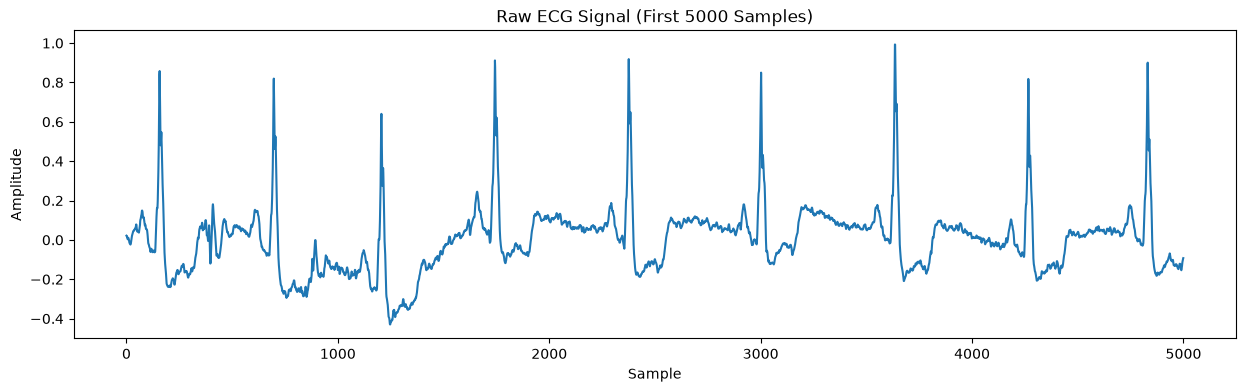

In [9]:
plt.figure(figsize=(15, 4))

plt.plot(ecg[:5000])

plt.title("Raw ECG Signal (First 5000 Samples)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

In [10]:
filtered_ecg = bandpass_filter(ecg)

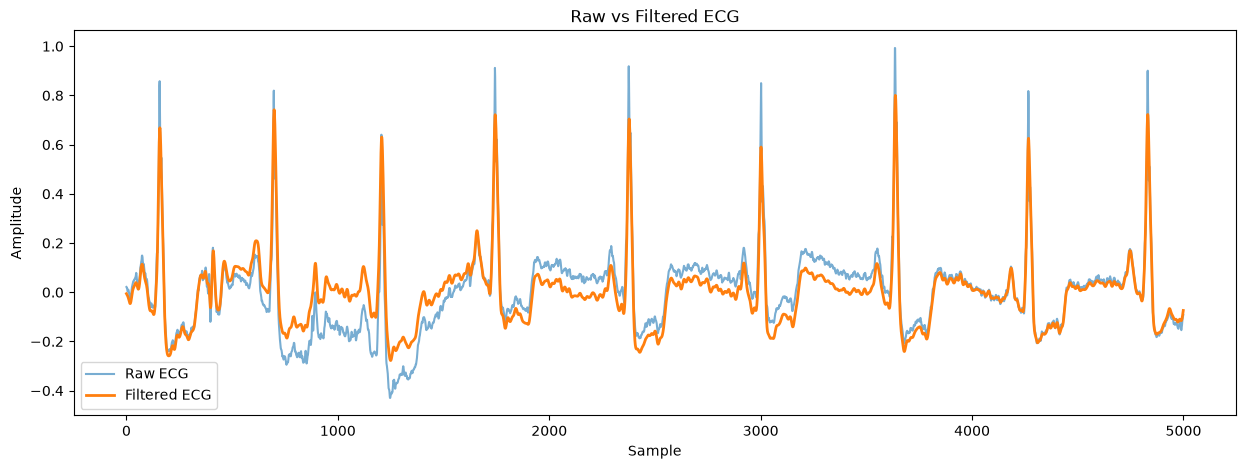

In [11]:
plt.figure(figsize=(15,5))

plt.plot(ecg[:5000], label="Raw ECG", alpha=0.6)
plt.plot(filtered_ecg[:5000], label="Filtered ECG", linewidth=2)

plt.title("Raw vs Filtered ECG")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Observations

- Applied a Butterworth band-pass filter (0.5–40 Hz) to the raw ECG signal.
- The filtered ECG shows a more stable baseline compared to the raw signal.
- High-frequency noise has been reduced while preserving the morphology of the ECG waveform.
- The R-peaks remain clearly visible after filtering.
- The filtered signal is suitable for reliable R-peak detection and HRV feature extraction.

In [12]:
labels = data["label"]

print(type(labels))
print(labels.shape)

print("\nUnique labels:")
print(np.unique(labels))

<class 'numpy.ndarray'>
(4255300,)

Unique labels:
[0 1 2 3 4 6 7]


In [13]:
for label in np.unique(labels):
    count = np.sum(labels == label)
    print(f"Label {label}: {count} samples")

Label 0: 2142701 samples
Label 1: 800800 samples
Label 2: 430500 samples
Label 3: 253400 samples
Label 4: 537599 samples
Label 6: 45500 samples
Label 7: 44800 samples


In [14]:
signals, info = detect_r_peaks(filtered_ecg)

In [15]:
print(info.keys())

dict_keys(['method_peaks', 'method_fixpeaks', 'ECG_R_Peaks', 'ECG_R_Peaks_Uncorrected', 'ECG_fixpeaks_ectopic', 'ECG_fixpeaks_missed', 'ECG_fixpeaks_extra', 'ECG_fixpeaks_longshort', 'ECG_fixpeaks_method', 'ECG_fixpeaks_rr', 'ECG_fixpeaks_drrs', 'ECG_fixpeaks_mrrs', 'ECG_fixpeaks_s12', 'ECG_fixpeaks_s22', 'ECG_fixpeaks_c1', 'ECG_fixpeaks_c2', 'sampling_rate', 'ECG_P_Peaks', 'ECG_P_Onsets', 'ECG_P_Offsets', 'ECG_Q_Peaks', 'ECG_R_Onsets', 'ECG_R_Offsets', 'ECG_S_Peaks', 'ECG_T_Peaks', 'ECG_T_Onsets', 'ECG_T_Offsets'])


In [16]:
r_peaks = info["ECG_R_Peaks"]

print("Number of detected R-peaks:", len(r_peaks))
print("First 10 R-peaks:")
print(r_peaks[:10])

Number of detected R-peaks: 7268
First 10 R-peaks:
[ 699 1208 1745 2379 3003 3638 4268 4832 5393 5940]


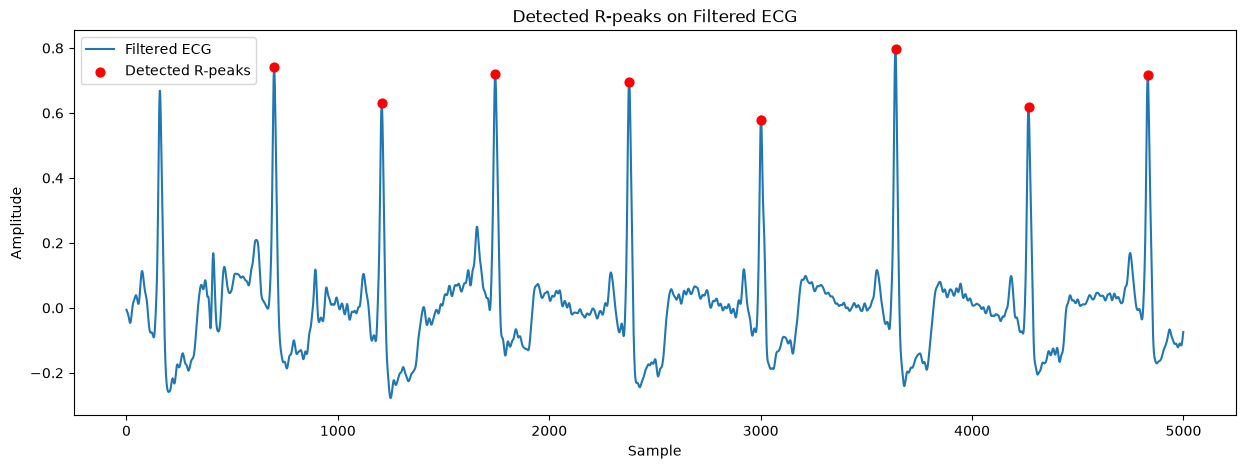

In [17]:
plt.figure(figsize=(15, 5))

plt.plot(filtered_ecg[:5000], label="Filtered ECG")

# Keep only peaks that are visible in the first 5000 samples
visible_peaks = r_peaks[r_peaks < 5000]

plt.scatter(
    visible_peaks,
    filtered_ecg[visible_peaks],
    color="red",
    s=40,
    label="Detected R-peaks",
    zorder=3,
)

plt.title("Detected R-peaks on Filtered ECG")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## R-Peak Detection

- The filtered ECG signal was processed using NeuroKit2.
- A total of 7,268 R-peaks were detected for Subject S2.
- The detected R-peaks align with the QRS complexes, indicating successful heartbeat detection.
- Accurate R-peak detection is essential for computing RR intervals and HRV features, which will be used in the fatigue classification model.

In [18]:
from src.hrv_features import compute_rr_intervals

ImportError: cannot import name 'compute_rr_intervals' from 'src.hrv_features' (c:\Users\arbaa\Desktop\ecg-fatigue-detection\src\hrv_features.py)

In [ ]:
rr_intervals = compute_rr_intervals(r_peaks)

print("Number of RR intervals:", len(rr_intervals))
print()
print("First 10 RR intervals (ms):")
print(rr_intervals[:10])

Number of RR intervals: 7267

First 10 RR intervals (ms):
[727.14285714 767.14285714 905.71428571 891.42857143 907.14285714
 900.         805.71428571 801.42857143 781.42857143 805.71428571]


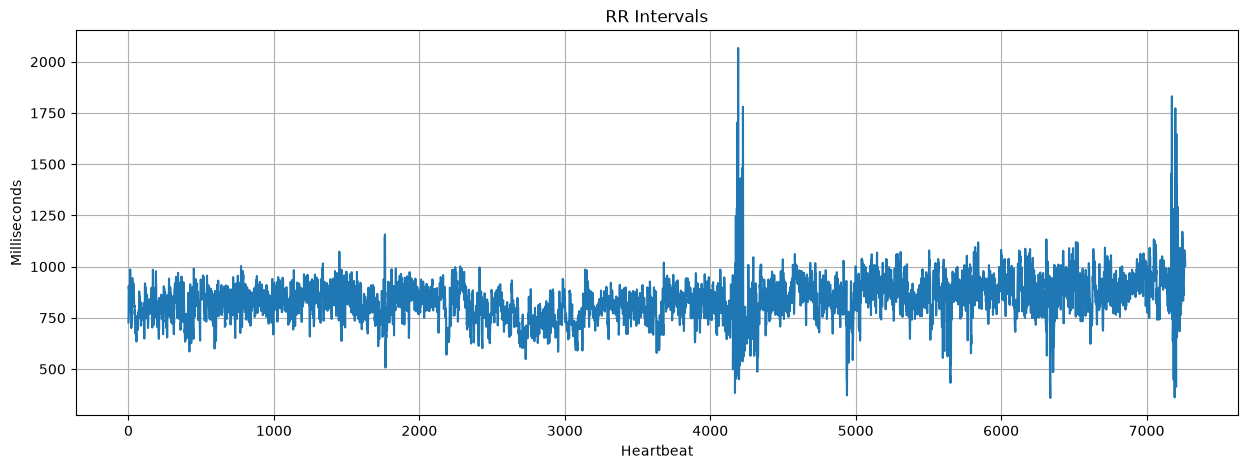

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(rr_intervals)

plt.title("RR Intervals")
plt.xlabel("Heartbeat")
plt.ylabel("Milliseconds")

plt.grid(True)

plt.show()

In [ ]:
from src.hrv_features import extract_hrv_features

In [ ]:
features = extract_hrv_features(rr_intervals)

features

{'Mean_RR': np.float64(836.2991212722877),
 'Mean_HR': np.float64(71.74466464668784),
 'SDNN': np.float64(105.13798619592804),
 'RMSSD': np.float64(83.65899616931135),
 'Min_RR': np.float64(358.5714285714286),
 'Max_RR': np.float64(2067.1428571428573),
 'Median_RR': np.float64(838.5714285714286)}

In [ ]:
for key, value in features.items():
    print(f"{key:12s}: {value:.2f}")

Mean_RR     : 836.30
Mean_HR     : 71.74
SDNN        : 105.14
RMSSD       : 83.66
Min_RR      : 358.57
Max_RR      : 2067.14
Median_RR   : 838.57


In [ ]:
from src.preprocessing import create_windows

In [ ]:
WINDOW_SECONDS = 30

SAMPLING_RATE = 700

WINDOW_SIZE = WINDOW_SECONDS * SAMPLING_RATE

STEP_SIZE = WINDOW_SIZE // 2      # 50% overlap

windows = create_windows(
    filtered_ecg,
    WINDOW_SIZE,
    STEP_SIZE
)

print("Number of windows:", len(windows))

Number of windows: 404


In [ ]:
print(windows[0].shape)

(21000,)


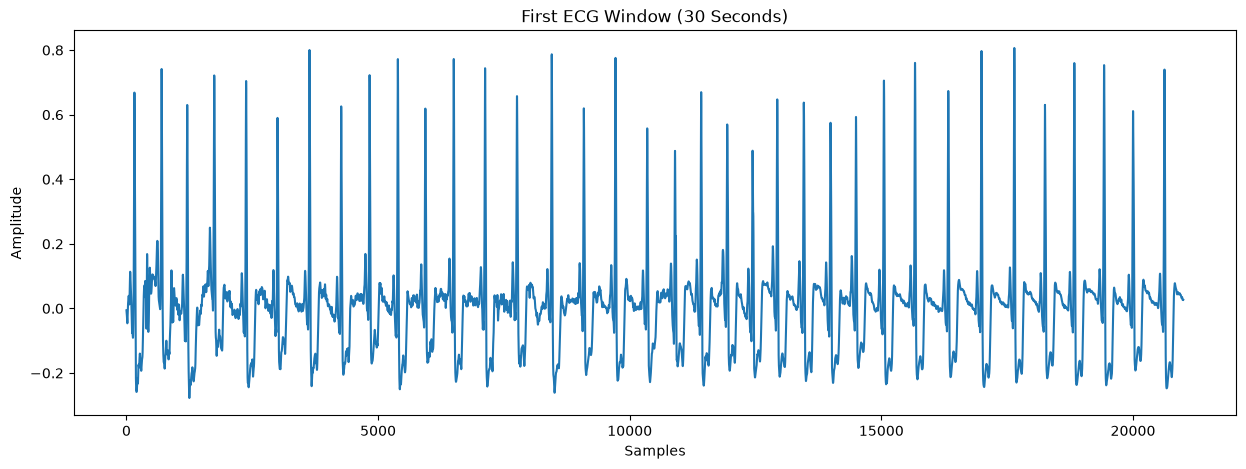

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(windows[0])

plt.title("First ECG Window (30 Seconds)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
feature_df = extract_hrv_features(windows[:20])

print(type(feature_df))

<class 'dict'>
